Gabarito das Questões sobre o Capítulo 9 - Modelos de Linguagem de Grande Porte Multimodais.

1 - Transformando imagem em patches (ideia do Vision Transformer)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.datasets import load_sample_image

# Primeiro carregamos uma imagem de exemplo do próprio sklearn
# apenas para usar como base no experimento
img = load_sample_image("china.jpg")

# Redimensionamos a imagem para 224x224 pixels
# Esse tamanho é bastante usado em modelos de visão computacional
img = Image.fromarray(img).resize((224,224))
img_array = np.array(img)

# Definimos o tamanho de cada pedaço da imagem (patch)
# Cada patch terá 16x16 pixels
patch_size = 16
patches = []

# Aqui percorremos a imagem inteira e vamos cortando
# pequenos quadrados de 16x16 pixels
# Cada quadrado é guardado na lista "patches"
for i in range(0, img_array.shape[0], patch_size):
    for j in range(0, img_array.shape[1], patch_size):
        patch = img_array[i:i+patch_size, j:j+patch_size]
        patches.append(patch)

# No final mostramos quantos pedaços foram criados
print("Imagem carregada!")
print("Número de patches:", len(patches))

Imagem carregada!
Número de patches: 196


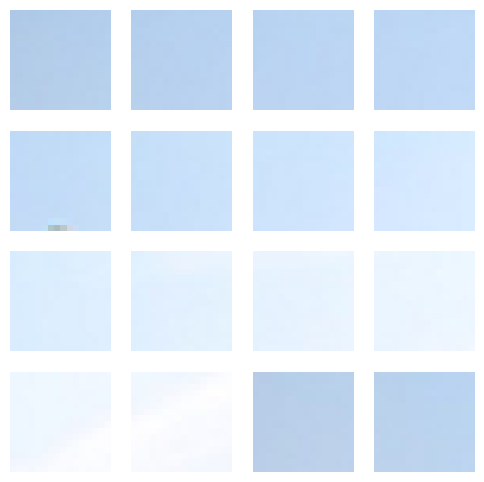

In [ ]:
# Criamos uma grade de gráficos 4x4 para mostrar alguns patches
# Isso vai permitir visualizar vários pedaços da imagem ao mesmo tempo
fig, axs = plt.subplots(4,4, figsize=(6,6))

# Pegamos os 16 primeiros patches e exibimos cada um
# em um dos espaços da grade criada acima
for ax, patch in zip(axs.flatten(), patches[:16]):
    ax.imshow(patch)   # mostra o patch
    ax.axis("off")     # remove os eixos para deixar a visualização mais limpa

# Exibe a janela com os patches
plt.show()

2 - Gerando embeddings de imagem e texto com CLIP

In [ ]:
# Instalamos as bibliotecas necessárias para rodar o exemplo
# transformers: modelos de IA prontos
# torch: framework de deep learning
# pillow: manipulação de imagens
!pip install transformers torch pillow

import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel


# Aqui carregamos o modelo CLIP já treinado pela OpenAI
# Esse modelo consegue relacionar imagens com textos
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


# Baixamos uma imagem da internet para usar no teste
url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131"
img_data = requests.get(url).content

# Salvamos a imagem localmente
with open("imagem.jpg", "wb") as f:
    f.write(img_data)

# Abrimos a imagem e garantimos que ela está no formato RGB
image = Image.open("imagem.jpg").convert("RGB")


# Aqui criamos algumas descrições de texto
# O modelo vai comparar esses textos com a imagem
texts = [
    "uma foto de um gato",
    "uma foto de um cachorro",
    "um carro"
]

print("Modelo e imagem carregados!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Modelo e imagem carregados!


In [ ]:
# O processor prepara os dados para o modelo
# Ele transforma os textos e a imagem em tensores que o modelo consegue entender
inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)

# Agora passamos esses dados para o modelo CLIP fazer a análise
outputs = model(**inputs)

# O modelo retorna pontuações que indicam o quanto cada texto
# combina com a imagem
logits_per_image = outputs.logits_per_image

# Aplicamos softmax para transformar essas pontuações em probabilidades
probs = logits_per_image.softmax(dim=1)

print("Probabilidade de correspondência:")

# Mostramos a probabilidade de cada texto descrever a imagem
for text, prob in zip(texts, probs[0]):
    print(text, ":", float(prob))

Probabilidade de correspondência:
uma foto de um gato : 0.9931437969207764
uma foto de um cachorro : 0.006709553301334381
um carro : 0.0001467278489144519


/tmp/ipykernel_229/3647320148.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(text, ":", float(prob))


3 - Busca de imagens usando texto (Search multimodal)

In [ ]:
# Instalamos as bibliotecas necessárias para usar o modelo
!pip install transformers torch pillow

import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests

# Carregamos o modelo CLIP já treinado
# Ele consegue relacionar imagens com descrições em texto
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Lista de imagens que vamos baixar para testar
urls = [
"https://images.unsplash.com/photo-1518791841217-8f162f1e1131",
"https://images.unsplash.com/photo-1552053831-71594a27632d",
"https://images.unsplash.com/photo-1446776811953-b23d57bd21aa"
]

images = []

# Baixamos cada imagem da lista
for i, url in enumerate(urls):
    img_data = requests.get(url).content
    filename = f"img{i}.jpg"

    # Salvamos a imagem no computador
    with open(filename, "wb") as f:
        f.write(img_data)

    # Abrimos a imagem e guardamos na lista
    images.append(Image.open(filename).convert("RGB"))

# Texto que vamos comparar com as imagens
# O modelo vai tentar descobrir qual imagem combina mais com essa descrição
text = ["foto de um gato"]

print("Imagens carregadas!")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Imagens carregadas!


In [ ]:
# O processor prepara os textos e as imagens
# convertendo tudo para o formato que o modelo consegue entender
inputs = processor(text=text, images=images, return_tensors="pt", padding=True)

# Enviamos esses dados para o modelo CLIP fazer a comparação
outputs = model(**inputs)

# O modelo retorna valores que indicam o quanto cada imagem
# combina com o texto fornecido
logits = outputs.logits_per_text

# Convertendo esses valores em probabilidades para facilitar a interpretação
probs = logits.softmax(dim=1)

print("Similaridade com 'foto de um gato':")

# Mostramos a probabilidade de cada imagem corresponder ao texto
for i, prob in enumerate(probs[0]):
    print(f"Imagem {i+1}: {float(prob):.3f}")

Similaridade com 'foto de um gato':
Imagem 1: 0.967
Imagem 2: 0.033
Imagem 3: 0.000


**QUESTÃO 4:** Complete o Pipeline do OpenCLIP
Abaixo, temos um trecho de código que tenta calcular a similaridade entre uma imagem e um texto. No entanto, faltam alguns passos cruciais para que o modelo funcione corretamente. Preencha as lacunas:


In [ ]:
#GABARITO QUESTÃO 4

from PIL import Image
import torch

# 1. Preparar os inputs (Texto e Imagem)
# A legenda é "an astronaut in the ocean" e a imagem já está carregada em 'img'
inputs = clip_tokenizer("an astronaut in the ocean", return_tensors="pt")

# RESPOSTA 1: A chave correta é "pixel_values"
processed_image = clip_processor(text=None, images=img, return_tensors="pt")["pixel_values"]

# 2. Extrair as representações numéricas (Embeddings)
with torch.no_grad():
    text_emb = model.get_text_features(**inputs)

    # RESPOSTA 2: Passamos a imagem pré-processada acima
    image_emb = model.get_image_features(processed_image)

# 3. Normalizar para calcular a similaridade de cosseno
# Isso garante que o vetor tenha comprimento 1
text_emb /= text_emb.norm(dim=-1, keepdim=True)
image_emb /= image_emb.norm(dim=-1, keepdim=True)

# 4. Calcular o score final usando o produto escalar (@)
similarity = (text_emb @ image_emb.T).item()

print(f"O nível de similaridade entre o texto e a imagem é: {similarity:.4f}")

**QUESTÃO 5**: Integrando Visão e Linguagem com BLIP-2
O BLIP-2 utiliza o Q-Former como uma ponte. Ele extrai características de uma imagem congelada e as projeta de forma que um LLM possa entendê-las como se fossem "palavras" (soft prompts). Complete as lacunas do código conceitual abaixo:

In [ ]:
#GABARITO QUESTÃO 5

import torch

# 1. Extração de características da imagem (Vision Transformer Congelado)
# O ViT processa os pixels e gera um mapa de características (embeddings)
with torch.no_grad():
    image_embeds = image_encoder(pix_values)

# 2. O Q-Former atua como o "tradutor"
# Ele usa Query Tokens aprendíveis para buscar informação na imagem
query_tokens = model.get_learnable_queries()

# RESPOSTA 1: O Q-Former recebe as 'image_embeds' como contexto (encoder_hidden_states)
query_output = q_former(query_tokens, encoder_hidden_states=image_embeds)

# 3. Projeção para o espaço do LLM
# Como o LLM e o Q-Former têm dimensões diferentes (ex: 4096 vs 768),
# precisamos de uma camada linear (Projector) para alinhar os tamanhos.

# RESPOSTA 2: Projetamos o 'query_output', que é a essência visual da imagem
inputs_llm = model.projector(query_output)

# 4. Geração de texto final
# O LLM recebe esses embeddings projetados como se fossem "palavras visuais"
output_text = llm.generate(inputs_embeds=inputs_llm, max_new_tokens=20)

print(f"O modelo descreveu a imagem como: {output_text}")